# Preliminary Analysis — Hybrid Quantum-Classical Comparison
**Controlled ablation study isolating the quantum circuit contribution in a hybrid model.**

## 1. Environment Setup

Install all required packages. The analysis in Sections 5-7 runs entirely on CPU;
GPU is only required for training (Section 4). If the environment has already been
configured for the companion QCNN Benchmark notebook, the cell below is a no-op.

In [1]:
# Install all required packages (re-run if any import fails).
%pip install -q pennylane==0.45.0 pennylane-lightning==0.45.0 \
              torch torchvision \
              numpy pandas matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, sys, json, glob, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 11})

ROOT    = Path.cwd()
RESULTS = ROOT / "results_ablation"

CLASS_NAMES = ["T-shirt", "Trouser", "Sneaker", "Bag"]
ARMS = ["trained", "frozen", "mlp8", "randfeat", "logistic"]
ARM_COLORS = {"trained":"#2196F3","frozen":"#03A9F4",
              "mlp8":"#FF9800","randfeat":"#FF5722","logistic":"#9E9E9E"}
ARM_LABELS = {"trained":"Quantum trained","frozen":"Quantum frozen",
              "mlp8":"MLP-8 (classical)","randfeat":"RandFeat (classical)",
              "logistic":"Logistic (trivial)"}

print(f"Results directory : {RESULTS}")
if RESULTS.exists():
    completed = list(RESULTS.rglob("test.json"))
    print(f"Completed runs    : {len(completed)}")
else:
    print("Results directory not found — expected results_ablation/ at repository root.")

Results directory : c:\Users\ferdi\Documents\Github\SEAI_project_BRUTTO\results_ablation
Completed runs    : 15


## 2. Ablation Design

Five arms share the same 8-feature classical head; only the feature extractor (256 → 8) varies:

```
                  TRAINABLE          FIXED (random)
              +-----------------+---------------------+
  QUANTUM     |    trained      |       frozen        |
              +-----------------+---------------------+
  CLASSICAL   |     mlp8        |      randfeat       |
              +-----------------+---------------------+
              + logistic  (trivial linear reference)
```

Same seed → same data split across all arms. Paired comparisons:

| Comparison | What it measures |
|------------|-----------------|
| `trained − mlp8` | Quantum vs. classical trainable extractor |
| `frozen − randfeat` | Quantum vs. classical random features |
| `trained − frozen` | Value of *learning* the circuit |
| `trained − logistic` | Hybrid model vs. trivial linear classifier |

## 3. Model Architecture

### 3.1 HybridFlatQCNN (quantum arms)

```
x ∈ ℝ^256
  → AmplitudeEmbedding(x, wires=0..7)      [fixed state-preparation circuit]
  → hur8 conv on all 8 wires (θ ∈ ℝ^10)   [learned or frozen]
  → ⟨Z⟩_0 … ⟨Z⟩_7                         [8 features in [−1, 1]]
  → LayerNorm(8) + Linear(8, 4)            [52 trainable head parameters]
  → logits ∈ ℝ^4
```

### 3.2 Classical Baselines

| Arm | Architecture | Trainable params |
|-----|-------------|:----------------:|
| `mlp8` | `Linear(256,8) → tanh → LayerNorm(8) → Linear(8,4)` | ~2 108 |
| `randfeat` | Fixed cos-random projection → head | 52 (head only) |
| `logistic` | `Linear(256, 4)` | 1 028 |

`randfeat` is iso-parameter with `frozen` (52 trainable parameters each). The frozen circuit **precomputes features once** per dataset, training only the head on cached tensors (~15× speedup).

In [3]:
import pennylane as qml

# -- Ansatz circuits (inlined) ------------------------------------------------

def hur6(theta, wires):
    """SO(4) circuit, 6 parameters."""
    a, b = wires
    qml.RY(theta[0], wires=a); qml.RY(theta[1], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RY(theta[2], wires=a); qml.RY(theta[3], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RY(theta[4], wires=a); qml.RY(theta[5], wires=b)

def hur8(theta, wires):
    """Hur 2022 baseline circuit, 10 parameters."""
    a, b = wires
    qml.RX(theta[0], wires=a); qml.RX(theta[1], wires=b)
    qml.RZ(theta[2], wires=a); qml.RZ(theta[3], wires=b)
    qml.RX(theta[4], wires=a); qml.RX(theta[5], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RX(theta[6], wires=a); qml.RX(theta[7], wires=b)
    qml.RZ(theta[8], wires=a); qml.RZ(theta[9], wires=b)

def hur9(theta, wires):
    """SU(4) / KAK circuit, 15 parameters."""
    a, b = wires
    qml.U3(theta[0], theta[1], theta[2], wires=a)
    qml.U3(theta[3], theta[4], theta[5], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RY(theta[6], wires=a); qml.RZ(theta[7], wires=b)
    qml.CNOT(wires=[b, a]); qml.RY(theta[8], wires=a)
    qml.CNOT(wires=[a, b])
    qml.U3(theta[9],  theta[10], theta[11], wires=a)
    qml.U3(theta[12], theta[13], theta[14], wires=b)

def custom_ansatz(theta, wires):
    """Cartan-inspired circuit, 11 parameters."""
    a, b = wires
    qml.RZ(theta[0], wires=a); qml.RY(theta[1], wires=a)
    qml.RZ(theta[2], wires=b); qml.RY(theta[3], wires=b)
    qml.IsingXX(theta[4], wires=[a, b])
    qml.IsingYY(theta[5], wires=[a, b])
    qml.IsingZZ(theta[6], wires=[a, b])
    qml.RY(theta[7], wires=a); qml.RZ(theta[8], wires=a)
    qml.RY(theta[9], wires=b); qml.RZ(theta[10], wires=b)

def conv_layer(conv_fn, theta, active_wires):
    """Translationally invariant conv: even + shifted pairs, shared params."""
    n = len(active_wires)
    even    = [(active_wires[i], active_wires[i+1]) for i in range(0, n-1, 2)]
    shifted = [(active_wires[i], active_wires[i+1]) for i in range(1, n-1, 2)]
    for pair in even + shifted:
        conv_fn(theta, pair)

print("Ansatz circuits defined.")

Ansatz circuits defined.


In [ ]:
# -- Visualise the HybridFlatQCNN quantum backbone ----------------------------
import torch
N = 8
dev = qml.device("default.qubit", wires=N)

@qml.qnode(dev)
def hybrid_circuit(x, theta):
    qml.AmplitudeEmbedding(x, wires=range(N), normalize=True)
    conv_layer(hur8, theta, list(range(N)))
    return [qml.expval(qml.PauliZ(w)) for w in range(N)]

x_d = torch.rand(2**N)
x_d /= x_d.norm()
theta_d = torch.zeros(10)
print("HybridFlatQCNN backbone  (AmplitudeEmbedding + hur8 flat conv, 8 <Z> readouts):")
print(qml.draw(hybrid_circuit)(x_d.numpy(), theta_d.numpy()))

HybridFlatQCNN backbone  (AmplitudeEmbedding + hur8 flat conv, 8 <Z> readouts):
0: ─╭|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╭●──RX(0.00)──RZ(0.00)───────────────────────────────── ···
1: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╰X──RX(0.00)──RZ(0.00)──RX(0.00)──RZ(0.00)──RX(0.00)─╭● ···
2: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╭●──RX(0.00)──RZ(0.00)──RX(0.00)──RZ(0.00)──RX(0.00)─╰X ···
3: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╰X──RX(0.00)──RZ(0.00)──RX(0.00)──RZ(0.00)──RX(0.00)─╭● ···
4: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╭●──RX(0.00)──RZ(0.00)──RX(0.00)──RZ(0.00)──RX(0.00)─╰X ···
5: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╰X──RX(0.00)──RZ(0.00)──RX(0.00)──RZ(0.00)──RX(0.00)─╭● ···
6: ─├|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╭●──RX(0.00)──RZ(0.00)──RX(0.00)──RZ(0.00)──RX(0.00)─╰X ···
7: ─╰|Ψ⟩──RX(0.00)──RZ(0.00)──RX(0.00)─╰X──RX(0.00)──RZ(0.00)───────────────────────────────── ···

0: ··· ─────────────────────┤  <Z>
1: ··· ──RX(0.00)──RZ(0.00)─┤  <Z>
2: ··· ──RX(0.00)──RZ(0.00)─┤  <Z>
3: ··· ──RX(0.00)──RZ(

## 4. Running the Experiments

> **Results are pre-computed and available in `results_ablation/`.**
> This section is provided for reference — proceed directly to Section 5 to load results.

The study covers 5 arms × 3 seeds = 15 runs. Each completed run produces a `test.json`
(test-set metrics) and a `metrics.csv` (per-epoch training curves) in its own subdirectory
of `results_ablation/`.

**Estimated GPU training time**: `trained` ~5–10 min / `frozen` ~2 min (feature caching)
/ `mlp8`, `randfeat`, `logistic` < 1 min each.

## 5. Loading Results

Scans `results_ablation/` recursively for `test.json` files (one per arm × seed subdirectory) and assembles a single DataFrame.

In [5]:
df3_raw = None
df3     = None

def _load_results_ablation(results_dir):
    """Scan results_dir recursively for test.json files and build a DataFrame."""
    records = []
    if not results_dir.exists():
        return records
    for test_json in sorted(results_dir.rglob("test.json")):
        run_dir = test_json.parent
        try:
            with open(test_json, encoding="utf-8") as f:
                rec = json.load(f)
            cm = rec.get("confusion_matrix", [[0] * 4 for _ in range(4)])
            flat_cm = {f"cm_{i}{j}": cm[i][j] for i in range(4) for j in range(4)}
            records.append({
                "arm":             rec.get("arm"),
                "seed":            rec.get("seed"),
                "n_params":        rec.get("n_params"),
                "n_epochs_trained":rec.get("n_epochs_trained"),
                "best_epoch":      rec.get("best_epoch"),
                "best_val_loss":   rec.get("best_val_loss"),
                "val_acc_best":    rec.get("val_acc_best"),
                "test_loss":       rec.get("test_loss"),
                "test_acc":        rec.get("test_acc"),
                **flat_cm,
                "_run_dir":        str(run_dir),
            })
        except Exception as exc:
            print(f"WARNING: could not load {test_json}: {exc}")
    return records

records3 = _load_results_ablation(RESULTS)

if not records3:
    print("WARNING: No completed runs found.")
    print("   -> Expected results in results_ablation/ at the repository root.")
else:
    df3 = pd.DataFrame(records3)
    for c in ["test_acc", "val_acc_best", "test_loss", "best_val_loss",
              "n_params", "best_epoch", "n_epochs_trained"]:
        if c in df3.columns:
            df3[c] = pd.to_numeric(df3[c], errors="coerce")

    print(f"[OK]  {len(df3)} runs loaded  |  "
          f"arms: {sorted(df3['arm'].unique())}  |  "
          f"seeds: {sorted(df3['seed'].unique())}")
    display(df3[["arm", "seed", "n_params", "n_epochs_trained",
                 "test_acc", "val_acc_best", "best_epoch"]]
            .sort_values(["arm", "seed"]).to_string(index=False))

[OK]  15 runs loaded  |  arms: ['frozen', 'logistic', 'mlp8', 'randfeat', 'trained']  |  seeds: [np.int64(42), np.int64(43), np.int64(44)]


'     arm  seed  n_params  n_epochs_trained  test_acc  val_acc_best  best_epoch\n  frozen    42        52                19    0.8990        0.9070          19\n  frozen    43        52                13    0.9160        0.9170          13\n  frozen    44        52                16    0.8650        0.8640          16\nlogistic    42      1028                20    0.9790        0.9830          20\nlogistic    43      1028                16    0.9815        0.9795          16\nlogistic    44      1028                19    0.9775        0.9865          19\n    mlp8    42      2108                16    0.9830        0.9845          16\n    mlp8    43      2108                 5    0.9810        0.9830           5\n    mlp8    44      2108                13    0.9810        0.9875          13\nrandfeat    42        52                19    0.8065        0.8265          19\nrandfeat    43        52                20    0.8900        0.8990          20\nrandfeat    44        52               

In [6]:
curves3 = {}
if RESULTS.exists():
    for p in sorted(RESULTS.rglob("metrics.csv")):
        if ".ipynb_checkpoints" in str(p):
            continue
        run = p.parent.name          # e.g. "trained_seed42"
        parts = run.rsplit("_seed", 1)
        if len(parts) == 2:
            key = parts[0]           # e.g. "trained"
            try:
                c = pd.read_csv(p)
                for col in ["train_loss","train_acc","val_loss","val_acc"]:
                    if col in c.columns:
                        c[col] = pd.to_numeric(c[col], errors="coerce")
                curves3.setdefault(key, []).append(c)
            except Exception:
                pass
print(f"Curves loaded: {sum(len(v) for v in curves3.values())} runs, "
      f"arms: {sorted(curves3.keys())}")

Curves loaded: 15 runs, arms: ['frozen', 'logistic', 'mlp8', 'randfeat', 'trained']


## 6. Analysis

### 6.1 Arm Comparison

Box plot of test accuracy distribution over the 3 seeds for each arm (box shows median
and interquartile range; dots show individual seed results). Colour distinguishes
quantum arms (blue) from classical arms (orange/red) and the trivial baseline (grey).

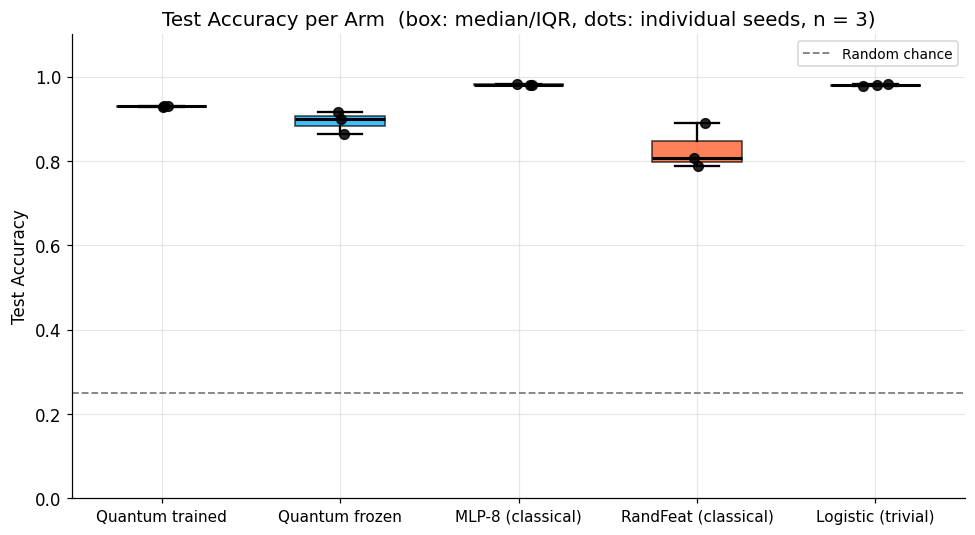

Arm comparison summary (mean ± std over 3 seeds):


'     arm  mean_acc  std_acc  n_seeds\n trained    0.9298   0.0025        3\n  frozen    0.8933   0.0260        3\n    mlp8    0.9817   0.0012        3\nrandfeat    0.8285   0.0540        3\nlogistic    0.9793   0.0020        3'

In [7]:
def _nd3(s): print(f"WARNING:  No data for {s} — ensure results_ablation/ is populated, then re-run Section 5.")

if df3 is None:
    _nd3("6.1")
else:
    present_arms = [a for a in ARMS if a in df3["arm"].unique()]
    box_data = [df3[df3["arm"] == arm]["test_acc"].values for arm in present_arms]

    fig, ax = plt.subplots(figsize=(9, 5))
    bp = ax.boxplot(box_data, positions=range(len(present_arms)), widths=0.5,
                    patch_artist=True,
                    medianprops={"color": "black", "lw": 2},
                    whiskerprops={"lw": 1.5}, capprops={"lw": 1.5},
                    flierprops={"marker": "o", "ms": 4})
    for patch, arm in zip(bp["boxes"], present_arms):
        patch.set_facecolor(ARM_COLORS.get(arm, "#9E9E9E"))
        patch.set_alpha(0.75)

    np.random.seed(0)
    for i, (arm, vals) in enumerate(zip(present_arms, box_data)):
        jitter = np.random.uniform(-0.08, 0.08, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color="black", s=40, zorder=5, alpha=0.85)

    ax.axhline(0.25, ls="--", color="gray", lw=1.2, label="Random chance")
    ax.set_xticks(range(len(present_arms)))
    ax.set_xticklabels([ARM_LABELS.get(a, a) for a in present_arms], fontsize=10)
    ax.set_ylabel("Test Accuracy")
    ax.set_ylim(0, 1.1)
    ax.set_title("Test Accuracy per Arm  (box: median/IQR, dots: individual seeds, n = 3)",
                 fontsize=13)
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

    # Numeric summary
    print("Arm comparison summary (mean ± std over 3 seeds):")
    grp_s = df3.groupby("arm")["test_acc"].agg(["mean", "std", "count"]).reset_index()
    grp_s["std"] = grp_s["std"].fillna(0)
    grp_s["_order"] = grp_s["arm"].map({a: i for i, a in enumerate(ARMS)}).fillna(99)
    grp_s = grp_s.sort_values("_order").drop(columns=["_order"]).reset_index(drop=True)
    display(grp_s.rename(columns={"mean": "mean_acc", "std": "std_acc",
                                   "count": "n_seeds"}).round(4).to_string(index=False))

### 6.2 Paired Delta Analysis

Within-seed accuracy deltas (same seed = same images). Eliminates data-sampling variance.
Positive Delta = first arm better; dots = per-seed deltas.

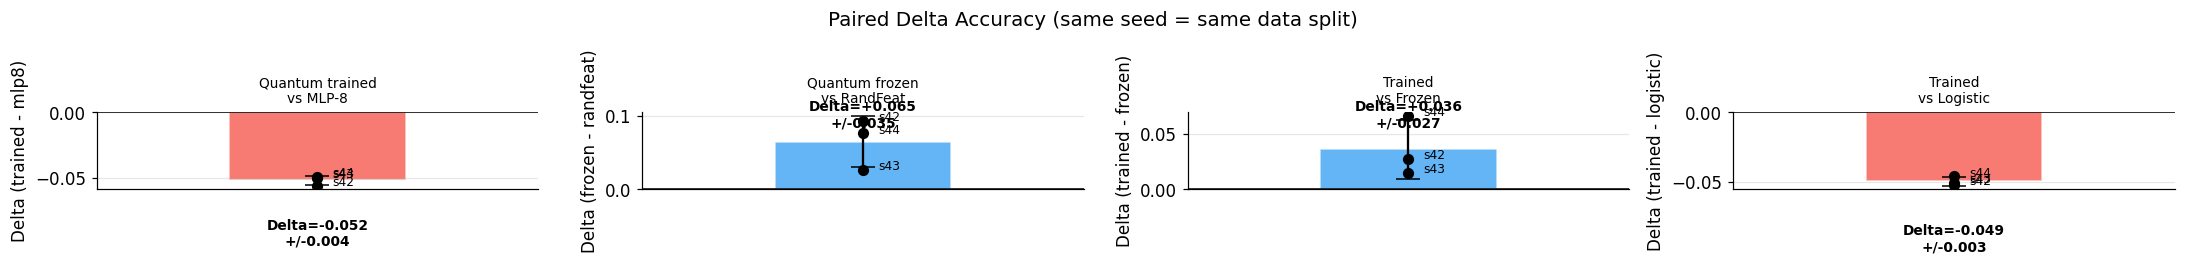


Paired delta summary:
  Comparison                mean Delta std Delta  per-seed
  trained - mlp8             -0.0518  0.0036  ['-0.0560', '-0.0500', '-0.0495']
  frozen - randfeat          +0.0648  0.0346  ['+0.0925', '+0.0260', '+0.0760']
  trained - frozen           +0.0365  0.0268  ['+0.0280', '+0.0150', '+0.0665']
  trained - logistic         -0.0495  0.0031  ['-0.0520', '-0.0505', '-0.0460']


In [8]:
if df3 is None:
    _nd3("6.2")
else:
    pivot3 = df3.pivot_table(index="seed", columns="arm", values="test_acc")
    seeds  = pivot3.index.tolist()

    COMPS = [
        ("trained","mlp8",    "Quantum trained\nvs MLP-8"),
        ("frozen", "randfeat","Quantum frozen\nvs RandFeat"),
        ("trained","frozen",  "Trained\nvs Frozen"),
        ("trained","logistic","Trained\nvs Logistic"),
    ]
    valid = [(a,b,l) for a,b,l in COMPS if a in pivot3.columns and b in pivot3.columns]

    if not valid:
        print("WARNING:  Not enough arms for paired deltas. Need >=2 arms completed.")
    else:
        fig, axes = plt.subplots(1, len(valid), figsize=(5*len(valid), 4.5))
        if len(valid) == 1: axes = [axes]
        for ax, (a1,a2,lbl) in zip(axes, valid):
            d = pivot3[a1] - pivot3[a2]
            mean_d, std_d = d.mean(), d.std()
            color = "#2196F3" if mean_d >= 0 else "#F44336"
            ax.bar([0], [mean_d], color=color, alpha=0.7, width=0.4,
                   yerr=std_d, capsize=8, edgecolor="white")
            for s, v in zip(seeds, d):
                ax.scatter(0, v, color="black", s=40, zorder=5)
                ax.annotate(f"s{s}", (0,v), textcoords="offset points",
                            xytext=(10,0), fontsize=8)
            ax.axhline(0, color="black", lw=1)
            ax.set_xlim(-0.5, 0.5); ax.set_xticks([])
            ax.set_ylabel(f"Delta ({a1} - {a2})")
            ax.set_title(lbl, fontsize=9)
            ax.text(0, mean_d+(0.02 if mean_d>=0 else -0.05),
                    f'Delta={mean_d:+.3f}\n+/-{std_d:.3f}',
                    ha="center", fontsize=9, fontweight="bold")
        fig.suptitle("Paired Delta Accuracy (same seed = same data split)", fontsize=13, y=1.02)
        plt.tight_layout(); plt.show()

        print("\nPaired delta summary:")
        print(f"  {'Comparison':<25} {'mean Delta':>8} {'std Delta':>7}  per-seed")
        for a1,a2,_ in valid:
            if a1 in pivot3.columns and a2 in pivot3.columns:
                d = pivot3[a1] - pivot3[a2]
                print(f"  {a1+' - '+a2:<25} {d.mean():>+8.4f} {d.std():>7.4f}  "
                      f"{[f'{v:+.4f}' for v in d.values]}")

### 6.3 Training Dynamics

Train accuracy (solid line) and validation accuracy (dashed line) for each arm,
mean ± std over seeds. A persistent gap between the two curves indicates overfitting.

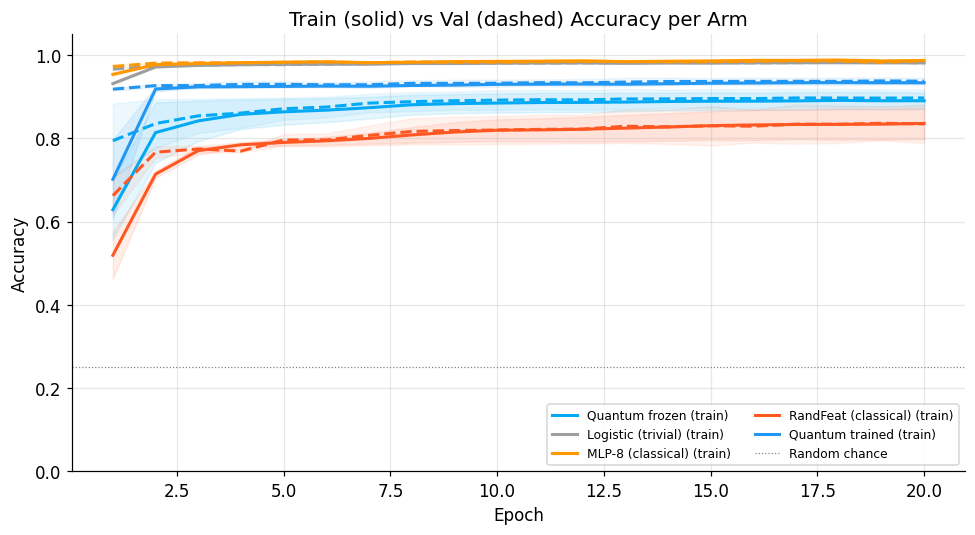

In [9]:
if not curves3:
    _nd3("6.3 - no metrics.csv found")
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    for arm, seed_dfs in sorted(curves3.items()):
        max_ep = max(c["epoch"].max() for c in seed_dfs)
        tr_mat = np.full((len(seed_dfs), int(max_ep)), np.nan)
        va_mat = np.full((len(seed_dfs), int(max_ep)), np.nan)
        for si, c in enumerate(seed_dfs):
            ep = c["epoch"].astype(int).values - 1
            for e, ta, va in zip(ep, c["train_acc"].values, c["val_acc"].values):
                if 0 <= e < int(max_ep):
                    tr_mat[si,e]=ta; va_mat[si,e]=va
        x = np.arange(1, int(max_ep)+1)
        color = ARM_COLORS.get(arm,"#9E9E9E")
        label = ARM_LABELS.get(arm,arm)
        m_tr = np.nanmean(tr_mat, 0); s_tr = np.nanstd(tr_mat, 0)
        m_va = np.nanmean(va_mat, 0); s_va = np.nanstd(va_mat, 0)
        ax.plot(x, m_tr, color=color, lw=2, label=f"{label} (train)")
        ax.fill_between(x, m_tr-s_tr, m_tr+s_tr, alpha=0.10, color=color)
        ax.plot(x, m_va, color=color, lw=2, ls="--")
        ax.fill_between(x, m_va-s_va, m_va+s_va, alpha=0.07, color=color)
    ax.axhline(0.25, ls=":", color="gray", lw=0.8, label="Random chance")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.set_ylim(0,1.05)
    ax.set_title("Train (solid) vs Val (dashed) Accuracy per Arm", fontsize=13)
    ax.legend(fontsize=8, loc="lower right", ncol=2)
    plt.tight_layout(); plt.show()

### 6.4 Confusion Matrices

One matrix per arm, summed over the three seeds. Cell values show absolute counts;
cell colour encodes the row-normalised fraction (recall per class).

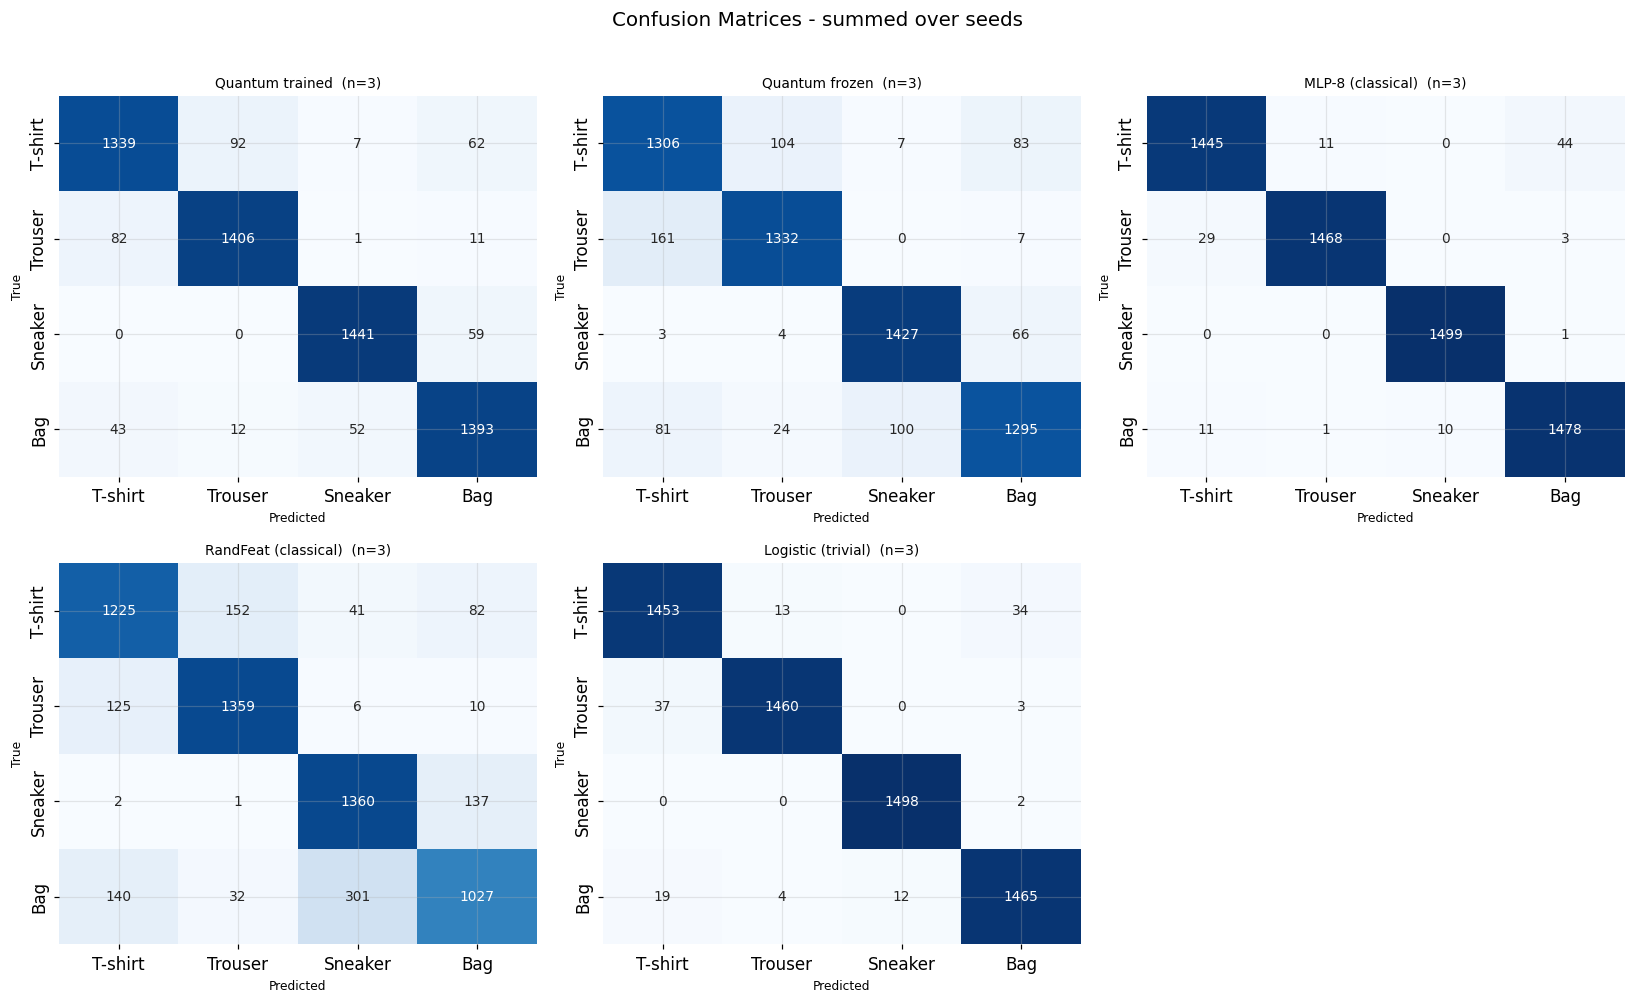

In [10]:
def _extract_cm(row, n=4):
    cm = np.zeros((n,n), dtype=int)
    for i in range(n):
        for j in range(n):
            col=f"cm_{i}{j}"
            if col in row.index and not pd.isna(row[col]):
                cm[i,j]=int(row[col])
    return cm

if df3 is None:
    _nd3("6.4")
else:
    present = [a for a in ARMS if a in df3["arm"].unique()]
    ncols = min(3, len(present)); nrows = (len(present)+ncols-1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols,4.5*nrows), squeeze=False)
    axf = axes.flatten()
    for idx, arm in enumerate(present):
        sub = df3[df3["arm"]==arm]
        cm = sum(_extract_cm(r) for _,r in sub.iterrows())
        norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
        sns.heatmap(norm, annot=cm, fmt="d", cmap="Blues", vmin=0, vmax=1,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    ax=axf[idx], cbar=False, annot_kws={"size":9})
        axf[idx].set_title(f"{ARM_LABELS.get(arm,arm)}  (n={len(sub)})", fontsize=9)
        axf[idx].set_xlabel("Predicted", fontsize=8); axf[idx].set_ylabel("True", fontsize=8)
    for ax in axf[len(present):]: ax.set_visible(False)
    fig.suptitle("Confusion Matrices - summed over seeds", fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

### 6.5 Cost Analysis

The encoding circuit dominates quantum inference cost: amplitude embedding of 256 pixel values on 8 qubits requires ~254 CNOTs (~97% of total CX budget). Full model: ~10 000 T-gates per inference vs. ~4 200 FLOPs for MLP-8.

Cost comparison:


'                   Arm Trainable params                 CNOT gates T-gates (eps=1e-3) FLOPs / inference\nQuantum trained/frozen               62 ~261 (enc: ~254, conv: ~7)            ~10 000       - (circuit)\n                  mlp8           ~2 108                          -                  -            ~4 200\n              randfeat               52                          -                  -            ~4 200\n              logistic             1028                          -                  -            ~2 048'


Key takeaway: the '10 trainable parameters' figure omits the encoding circuit.
Counting the full quantum model: ~10^4 T-gates vs ~10^3 FLOPs for the classical twin.


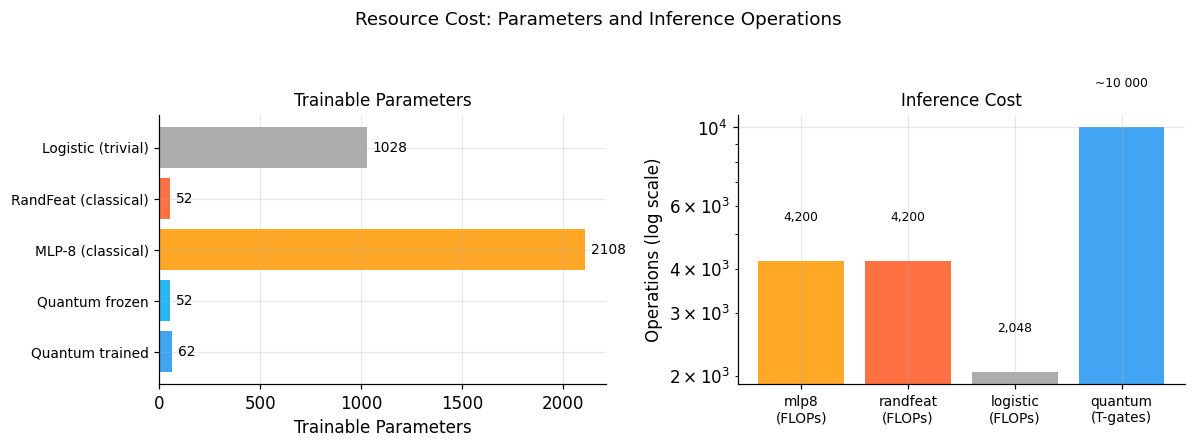

In [11]:
# Static cost figures (analytical)
COST = {
    "Arm":              ["Quantum trained/frozen", "mlp8",   "randfeat", "logistic"],
    "Trainable params": [62,                        "~2 108", 52,         1028],
    "CNOT gates":       ["~261 (enc: ~254, conv: ~7)", "-",  "-",        "-"],
    "T-gates (eps=1e-3)": ["~10 000",                "-",     "-",        "-"],
    "FLOPs / inference":["- (circuit)",            "~4 200", "~4 200",   "~2 048"],
}
print("Cost comparison:")
display(pd.DataFrame(COST).to_string(index=False))
print()
print("Key takeaway: the '10 trainable parameters' figure omits the encoding circuit.")
print("Counting the full quantum model: ~10^4 T-gates vs ~10^3 FLOPs for the classical twin.")

fig, axes = plt.subplots(1,2, figsize=(11,4))

arms_p = ["trained","frozen","mlp8","randfeat","logistic"]
params_ = [62, 52, 2108, 52, 1028]
axes[0].barh(range(5), params_, color=[ARM_COLORS[a] for a in arms_p], alpha=0.85)
axes[0].set_yticks(range(5)); axes[0].set_yticklabels([ARM_LABELS[a] for a in arms_p], fontsize=9)
axes[0].set_xlabel("Trainable Parameters"); axes[0].set_title("Trainable Parameters", fontsize=11)
for i,v in enumerate(params_): axes[0].text(v+30, i, str(v), va="center", fontsize=9)

cl_names = ["mlp8","randfeat","logistic"]; cl_flops = [4200,4200,2048]
axes[1].bar([0,1,2], cl_flops, color=[ARM_COLORS[a] for a in cl_names], alpha=0.85)
axes[1].bar([3], [10000], color=ARM_COLORS["trained"], alpha=0.85)
axes[1].set_yscale("log")
axes[1].set_xticks([0,1,2,3])
axes[1].set_xticklabels(["mlp8\n(FLOPs)","randfeat\n(FLOPs)","logistic\n(FLOPs)","quantum\n(T-gates)"], fontsize=9)
axes[1].set_ylabel("Operations (log scale)"); axes[1].set_title("Inference Cost", fontsize=11)
for i,v in enumerate(cl_flops): axes[1].text(i, v*1.3, f"{v:,}", ha="center", fontsize=8)
axes[1].text(3, 10000*1.3, "~10 000", ha="center", fontsize=8)
fig.suptitle("Resource Cost: Parameters and Inference Operations", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()